# I: Introduction:

À l’ère de l’intelligence artificielle, la détection des défauts de fabrication sur les machines industrielles est devenue un domaine de recherche et d’application particulièrement actif. Traditionnellement, ces opérations sont réalisées par des opérateurs humains ou à l’aide de règles déterministes. Toutefois, ces approches deviennent de plus en plus complexes et limitées face à la diversité des produits, à la variété des anomalies (des anomalies de tailles différentes, localisées ou diffuses) et à l’augmentation des cadences de production, rendant les processus de contrôle coûteux, lents et pas très fiables.

Le contrôle qualité automatisé occupe aujourd’hui une place essentielle dans de nombreux secteurs industriels. La détection précoce des anomalies permet non seulement de réduire les coûts liés aux retouches et aux rebuts des pièces produites, mais également d’améliorer la fiabilité des produits, d’augmenter les volumes de production et de satisfaire des clients.

Dans ce contexte, l’IA s’est imposée comme une solution incontournable pour remplacer les méthodes traditionnelles, en proposant des systèmes de détection d’anomalies plus rapides, plus fiables. De nombreuses approches ont été développées pour automatiser le contrôle de la qualité des pièces industrielles, notamment la détection d’anomalies visuelles à partir d’images. Plusieurs approches de machine learning et de deep learning (séparément ou combinées) permettent de réaliser des modèles qui détectent ces anomalies à la perfection très tôt dans la chaîne de production.

Cependant, la détection d’anomalies industrielles reste un problème complexe. Les défauts sont souvent rares, imprévisibles et présentent une grande diversité de formes, de tailles et de localisations. Les variations naturelles liées aux conditions d’acquisition des images (la luminosité, l’orientation, le zoom ou la texture)  peuvent être confondues avec de véritables défauts.  Ces contraintes rendent difficile la constitution d’un jeu de données exhaustif et équilibré.

Dans le cadre de notre projet,  nous allons étudier et comparer plusieurs méthodes et approches de détection d’anomalie visuelles sur le jeux de données MTVec en s’appuyant sur des méthodes de machine learning et de deep learning.

Le projet suivra plusieurs étapes , incluant le pre-processing des données brut, l'entraînement des différents modèles  et enfin l'évaluation et la performance de chaque modèle.


## I. Exploration des données des MvTec Anamoly Detection Project individuellement:

Ce code permet d'extraire les informations de la distribution de la couleurs RGB ou en gris, la distribution de la luminosité, de la taille des images et aussi la comparaison entre les image avec anomalie et leurs mask. *Nous allons effectuer les même operations sur toutes les pieces industrielles et ensuite faire une comparaison pour voir s'il y'a une différence de taille, de cannaux entre les images des différentes pieces industrielles étudiées*:

In [ ]:
## importation des librairies utilisées pour l'exploration des données:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import seaborn as sns

from PIL import Image
from pathlib import Path
from collections import Counter

## 1) la piece industrielle **bottle**

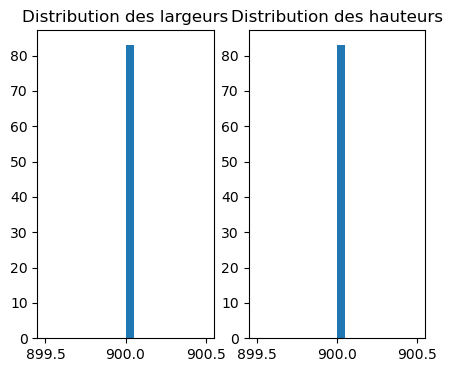

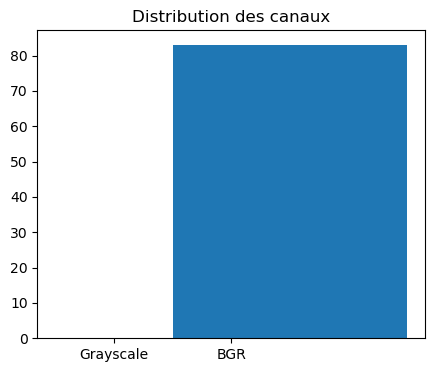

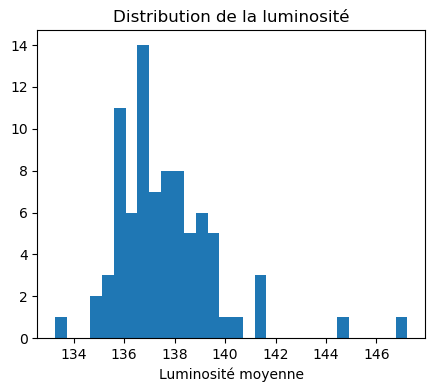

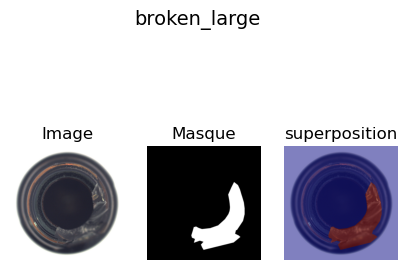

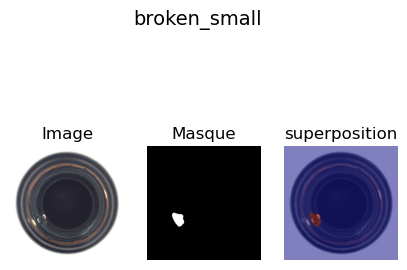

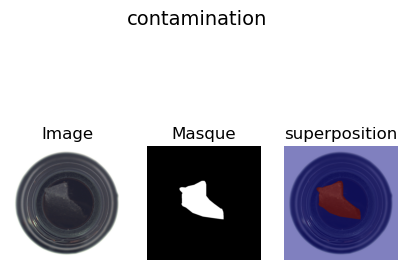

 le nombre d'image total est de : 83
 le nombre d'image non lues est de : 0
liste des informations de chaque pièces: [{'path': 'C:\\Users\\hanou\\OneDrive\\Formation_DS\\Projet\\mvtec_anomaly_detection\\bottle\\test\\broken_large\\000.png', 'width': 900, 'height': 900, 'channels': 3, 'brightness': np.float64(138.37204691358025), 'label': 'broken_large'}, {'path': 'C:\\Users\\hanou\\OneDrive\\Formation_DS\\Projet\\mvtec_anomaly_detection\\bottle\\test\\broken_large\\001.png', 'width': 900, 'height': 900, 'channels': 3, 'brightness': np.float64(134.7255086419753), 'label': 'broken_large'}, {'path': 'C:\\Users\\hanou\\OneDrive\\Formation_DS\\Projet\\mvtec_anomaly_detection\\bottle\\test\\broken_large\\002.png', 'width': 900, 'height': 900, 'channels': 3, 'brightness': np.float64(135.7949987654321), 'label': 'broken_large'}, {'path': 'C:\\Users\\hanou\\OneDrive\\Formation_DS\\Projet\\mvtec_anomaly_detection\\bottle\\test\\broken_large\\003.png', 'width': 900, 'height': 900, 'channels': 3, 

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles ## initialisation des chemins pour accéder au dossier et sous dossiers.
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = [] ##ajout d'un dictionnaire vide pour enregistrer toutes les informations extraite de chaque image.

###fonction qui permet d'extraire les informations des images de test:
    def load_images_info(self):
        self.total_image=0     ## on ajoute un conteur pour calculer le nombre d'image total dans chaque dossier
        self.no_read_image=0      ## on ajoute un conteur pour calculer le nombre d'image non lue dans chaque dossier

        for root, _, files in os.walk(self.test_path):    ## lire les dossier et sous-dossiers
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):   ### lire les images avec les format png, jpg et jpeg
                    img_path = os.path.join(root, file)   ##ajouter le nom de l'image au non du sous-dossier
                    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)     ##lire l'image
                    self.total_image+=1 ## ajouter 1 à chaque fois qu'une image est lue

                    if img is None: ##
                        self.no_read_image+=1   ##ajouter 1 à chasue fois qu'une image n'a pas été lue
                        continue

                    h, w = img.shape[:2]   ##  extraire les longeur et largeur de l'image
                    channels = img.shape[2] if len(img.shape) == 3 else 1  ##  extraire si l'image est en gris ou  en RGB
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  ##  tranformer les images en gris afin de leurs appliquer
                    brightness = gray.mean()  ## calcule de la luminausité de chaque image

                    label = os.path.basename(root) ##


                    ## Ajout des informations de chaque image dans la liste image_infon
                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })

                    image_info= pd.DataFrame(self.image_info)


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_bottle = [info["width"] for info in self.image_info]
        heights_bottle = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_bottle, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_bottle, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_bottle = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_bottle, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "BGR"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_bottle = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_bottle, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()



## superposition des images avec anomalies et leurs mask: on prent quelques echantillions à chaque fois.
    def show_image_with_mask(self, anomaly_type):
        img_dir = os.path.join(self.test_path, anomaly_type)
        mask_dir = os.path.join(self.mask_path, anomaly_type)

        img_files = [f for f in os.listdir(img_dir) if f.endswith(".png")]
        mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".png")]

        if len(img_files) == 0 or len(mask_files) == 0:
            print("Aucune image ou masque trouvé")
            return

        img_name = img_files[0]
        mask_name = img_name.replace(".png", "_mask.png")

        img = cv2.imread(os.path.join(img_dir, img_name))
        mask = cv2.imread(os.path.join(mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print("Erreur de chargement image ou masque")
            return

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(5,4))
        subplot_titles = ["Anomalie bent", "Anomalie crack", "Anomalie hole"]

        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")


        plt.subplot(1,3,2)
        plt.imshow(mask, cmap="gray")
        plt.title("Masque")
        plt.axis("off")


        plt.subplot(1,3,3)
        plt.imshow(img)
        plt.imshow(mask, cmap="jet", alpha=0.5)
        plt.title("superposition")
        plt.axis("off")

        plt.suptitle(f"{anomaly_type}", fontsize=14)


        plt.show()

## calculer le nombre d'image non lues par rapport au nombre d'image total:
    def image_counts(self):
        print(f" le nombre d'image total est de : {self.total_image}")
        print(f" le nombre d'image non lues est de : {self.no_read_image}")
        print(f"liste des informations de chaque pièces: {self.image_info}")

## le chemin des données de chaque pièce :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\bottle"


## Appel des fonctions:
explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()
explorer.show_image_with_mask("broken_large")
explorer.show_image_with_mask("broken_small")
explorer.show_image_with_mask("contamination")
explorer.image_counts()

## 2) La piece industrielle **cable**:

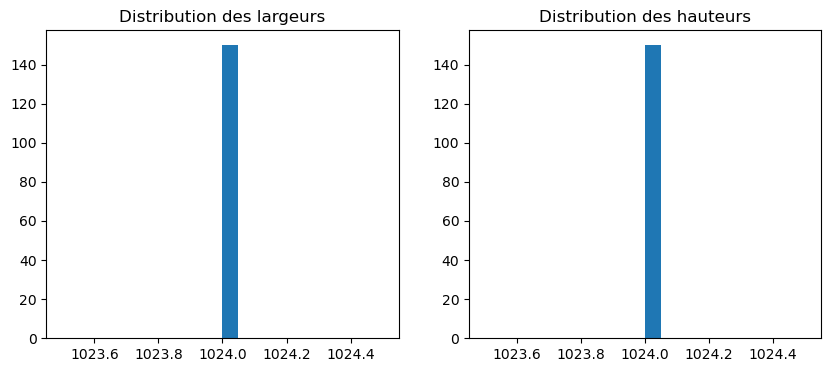

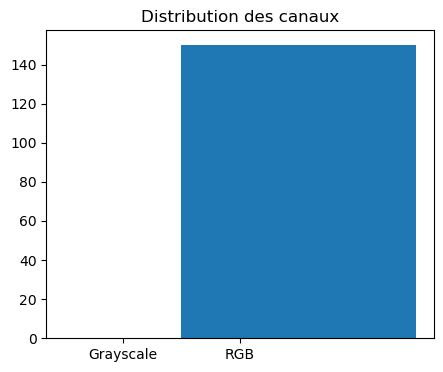

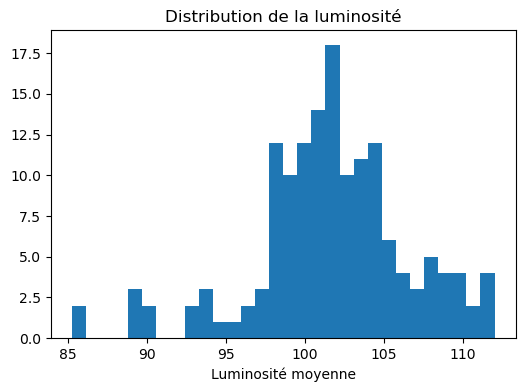

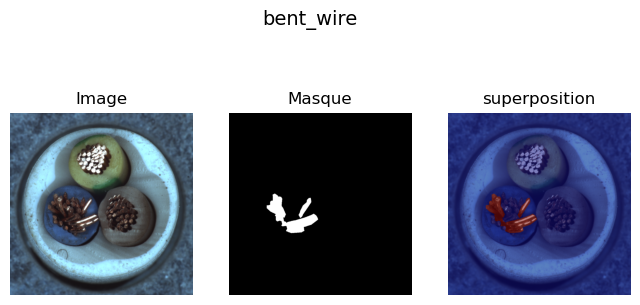

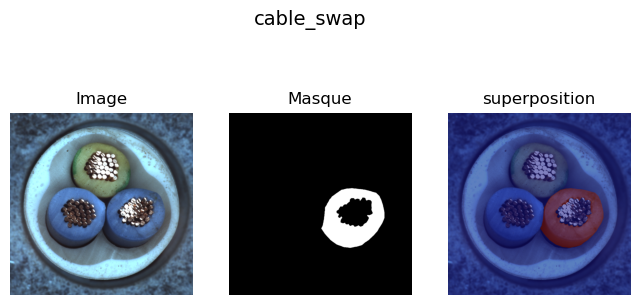

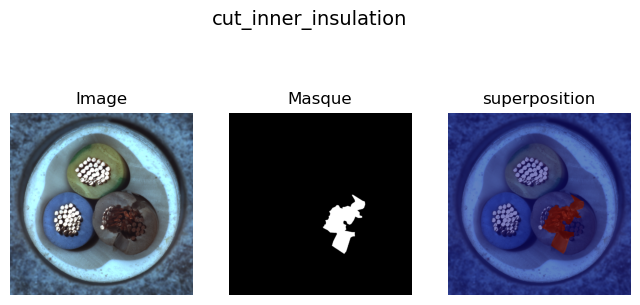

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_cable = [info["width"] for info in self.image_info]
        heights_cable = [info["height"] for info in self.image_info]

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.hist(widths_cable, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_cable, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_cable = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_cable, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_cable = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(6,4))
        plt.hist(brightness_cable, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()



##
    def show_image_with_mask(self, anomaly_type):
        img_dir = os.path.join(self.test_path, anomaly_type)
        mask_dir = os.path.join(self.mask_path, anomaly_type)

        img_files = [f for f in os.listdir(img_dir) if f.endswith(".png")]
        mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".png")]

        if len(img_files) == 0 or len(mask_files) == 0:
            print("Aucune image ou masque trouvé")
            return

        img_name = img_files[0]
        mask_name = img_name.replace(".png", "_mask.png")

        img = cv2.imread(os.path.join(img_dir, img_name))
        mask = cv2.imread(os.path.join(mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print("Erreur de chargement image ou masque")
            return

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,4))


        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")


        plt.subplot(1,3,2)
        plt.imshow(mask, cmap="gray")
        plt.title("Masque")
        plt.axis("off")


        plt.subplot(1,3,3)
        plt.imshow(img)
        plt.imshow(mask, cmap="jet", alpha=0.5)
        plt.title("superposition")
        plt.axis("off")

        plt.suptitle(f"{anomaly_type}", fontsize=14)


        plt.show()



## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\cable"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()
explorer.show_image_with_mask("bent_wire")
explorer.show_image_with_mask("cable_swap")
explorer.show_image_with_mask("cut_inner_insulation")


## 3) Pièce industrielle **capsule**:

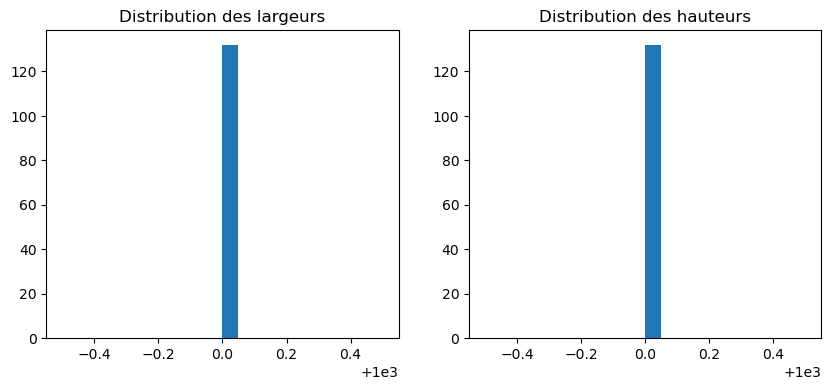

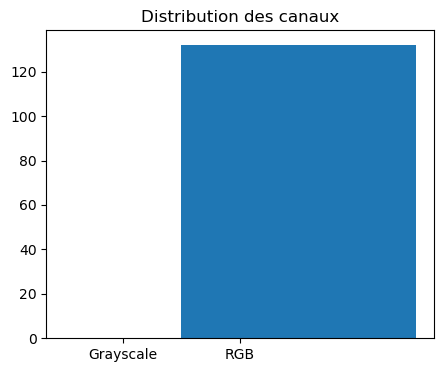

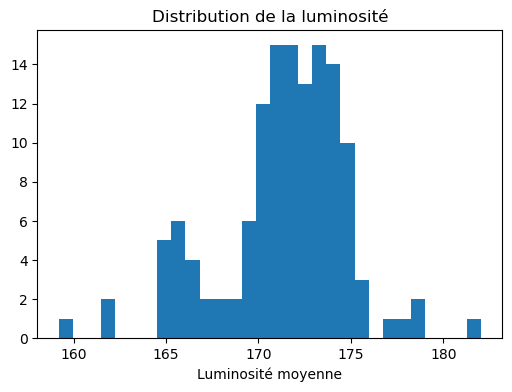

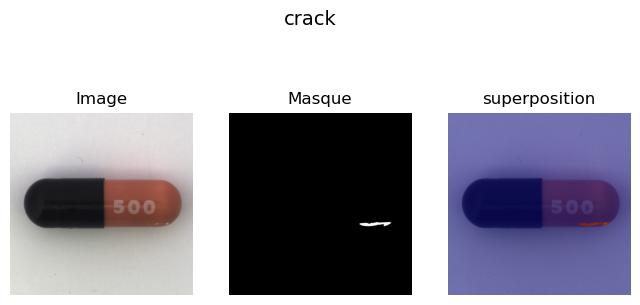

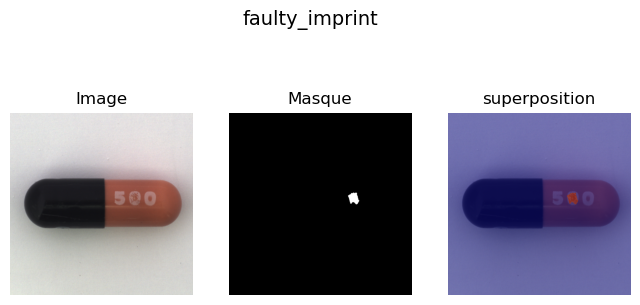

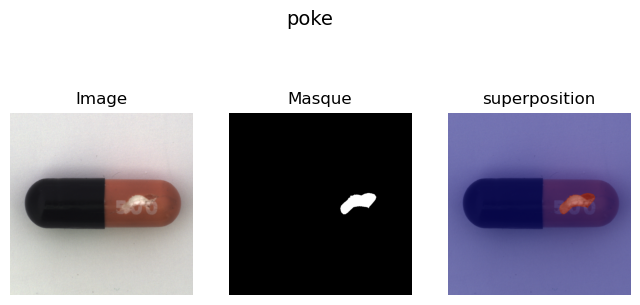

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        #self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

### fonction qui permet d'extraires les caracteristiques des images de chaque piece industrielle:
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_capsule= [info["width"] for info in self.image_info]
        heights_capsule = [info["height"] for info in self.image_info]

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        plt.hist(widths_capsule, bins=20)
        plt.title("Distribution des largeurs")


        plt.subplot(1,2,2)
        plt.hist(heights_capsule, bins=20)
        plt.title("Distribution des hauteurs")


        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_capsule = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_capsule, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_capsule = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(6,4))
        plt.hist(brightness_capsule, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()



##
    def show_image_with_mask(self, anomaly_type):
        img_dir = os.path.join(self.test_path, anomaly_type)
        mask_dir = os.path.join(self.mask_path, anomaly_type)

        img_files = [f for f in os.listdir(img_dir) if f.endswith(".png")]
        mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".png")]

        if len(img_files) == 0 or len(mask_files) == 0:
            print("Aucune image ou masque trouvé")
            return

        img_name = img_files[0]
        mask_name = img_name.replace(".png", "_mask.png")

        img = cv2.imread(os.path.join(img_dir, img_name))
        mask = cv2.imread(os.path.join(mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print("Erreur de chargement image ou masque")
            return

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8,4))


        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")


        plt.subplot(1,3,2)
        plt.imshow(mask, cmap="gray")
        plt.title("Masque")
        plt.axis("off")


        plt.subplot(1,3,3)
        plt.imshow(img)
        plt.imshow(mask, cmap="jet", alpha=0.5)
        plt.title("superposition")
        plt.axis("off")

        plt.suptitle(f"{anomaly_type}", fontsize=14)


        plt.show()



## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\capsule"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()
explorer.show_image_with_mask("crack")
explorer.show_image_with_mask("faulty_imprint")
explorer.show_image_with_mask("poke")


In [ ]:
img=cv2.imread(r"C:\Users\hanou\OneDrive\Formation_DS\Projet\test_taille\000.png")

if img is not None:
    height, width = img.shape[:2]  # img.shape -> (hauteur, largeur, canaux)
    print(f"Taille de l'image : {width} x {height} pixels")
else:
    print("Erreur : l'image n'a pas été trouvée")

Taille de l'image : 1000 x 1000 pixels


In [ ]:
withs=[]
heights=[]
for i in os.listdir(df):
    if i.endswith((".png",".jpg"," jpeg")):
        img_path = os.path.join(folder_path, file_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w = img.shape[:2]  # img.shape -> (hauteur, largeur, canaux)
            widths.append(w)
            heights.append(h)
print(heights)

[]


## 4) Pièce industrielle **carpet**:

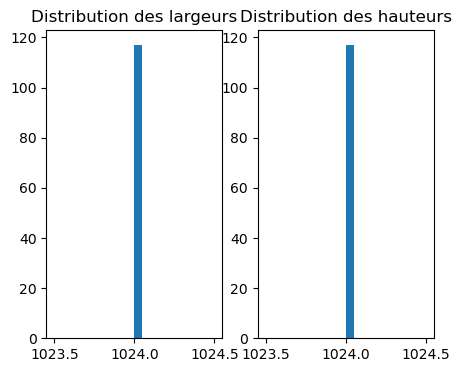

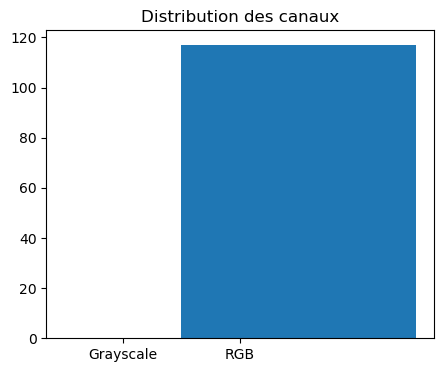

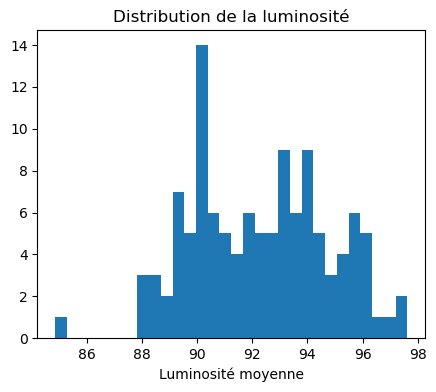

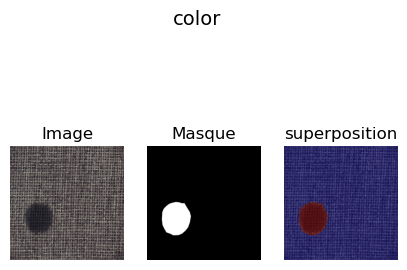

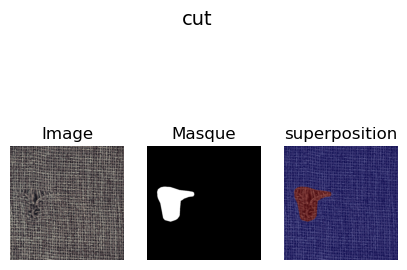

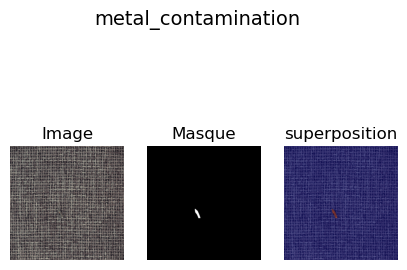

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_carpet = [info["width"] for info in self.image_info]
        heights_carpet = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_carpet, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_carpet, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_carpet = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_carpet, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_carpet = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_carpet, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()



##
    def show_image_with_mask(self, anomaly_type):
        img_dir = os.path.join(self.test_path, anomaly_type)
        mask_dir = os.path.join(self.mask_path, anomaly_type)

        img_files = [f for f in os.listdir(img_dir) if f.endswith(".png")]
        mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".png")]

        if len(img_files) == 0 or len(mask_files) == 0:
            print("Aucune image ou masque trouvé")
            return

        img_name = img_files[0]
        mask_name = img_name.replace(".png", "_mask.png")

        img = cv2.imread(os.path.join(img_dir, img_name))
        mask = cv2.imread(os.path.join(mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print("Erreur de chargement image ou masque")
            return

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(5,4))
        #subplot_titles = ["Anomalie bent", "Anomalie crack", "Anomalie hole"]

        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")


        plt.subplot(1,3,2)
        plt.imshow(mask, cmap="gray")
        plt.title("Masque")
        plt.axis("off")


        plt.subplot(1,3,3)
        plt.imshow(img)
        plt.imshow(mask, cmap="jet", alpha=0.5)
        plt.title("superposition")
        plt.axis("off")

        plt.suptitle(f"{anomaly_type}", fontsize=14)


        plt.show()



## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\carpet"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()
explorer.show_image_with_mask("color")
explorer.show_image_with_mask("cut")
explorer.show_image_with_mask("metal_contamination")


## 5) Pièce industrielle **grid**:

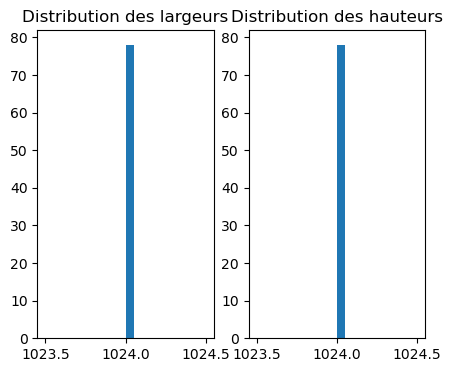

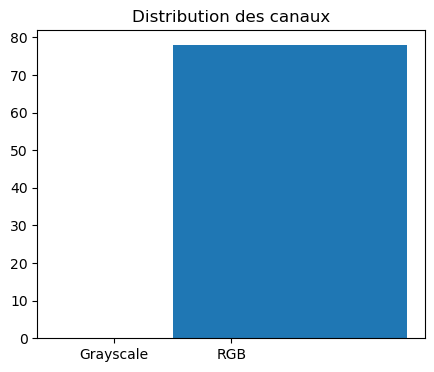

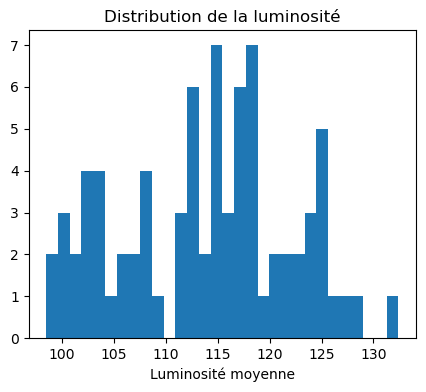

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_grid = [info["width"] for info in self.image_info]
        heights_grid = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_grid, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_grid, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_grid = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_grid, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_grid = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_grid, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()



##
    def show_image_with_mask(self, anomaly_type):
        img_dir = os.path.join(self.test_path, anomaly_type)
        mask_dir = os.path.join(self.mask_path, anomaly_type)

        img_files = [f for f in os.listdir(img_dir) if f.endswith(".png")]
        mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".png")]

        if len(img_files) == 0 or len(mask_files) == 0:
            print("Aucune image ou masque trouvé")
            return

        img_name = img_files[0]
        mask_name = img_name.replace(".png", "_mask.png")

        img = cv2.imread(os.path.join(img_dir, img_name))
        mask = cv2.imread(os.path.join(mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print("Erreur de chargement image ou masque")
            return

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(5,4))
        #subplot_titles = ["Anomalie bent", "Anomalie crack", "Anomalie hole"]

        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")


        plt.subplot(1,3,2)
        plt.imshow(mask, cmap="gray")
        plt.title("Masque")
        plt.axis("off")


        plt.subplot(1,3,3)
        plt.imshow(img)
        plt.imshow(mask, cmap="jet", alpha=0.5)
        plt.title("superposition")
        plt.axis("off")

        plt.suptitle(f"{anomaly_type}", fontsize=14)


        plt.show()



## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\grid"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## 6) Pièce industrielle **hazelnut**:

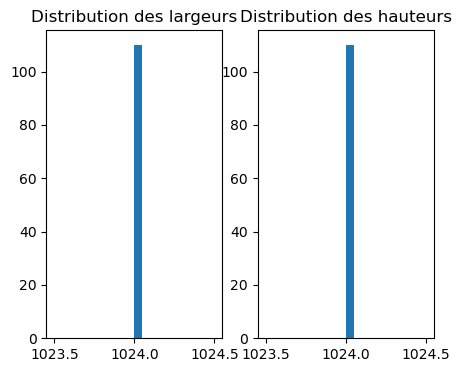

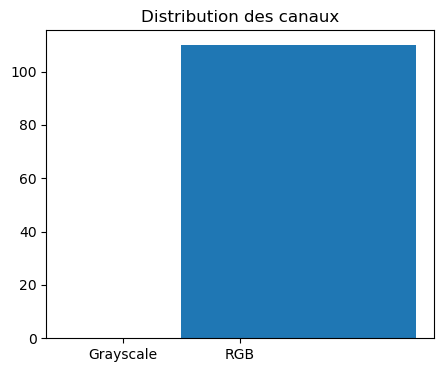

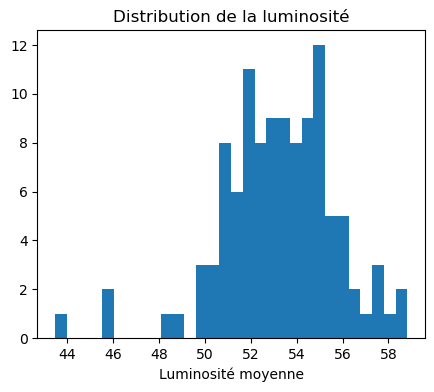

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_hazelnut = [info["width"] for info in self.image_info]
        heights_hazelnut = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_hazelnut, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_hazelnut, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_hazelnut = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_hazelnut, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_hazelnut = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_hazelnut, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\hazelnut"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## 7) Pièce industrielle **leather**:

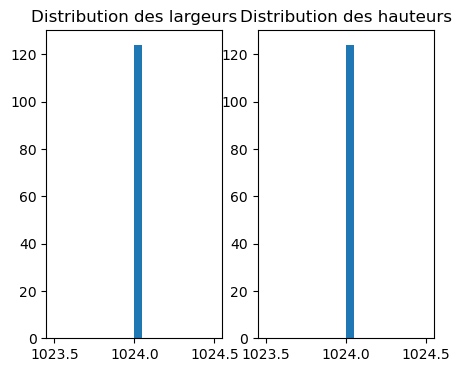

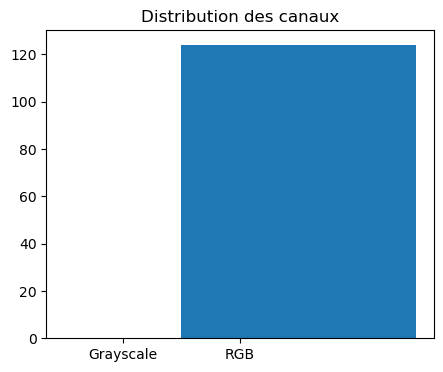

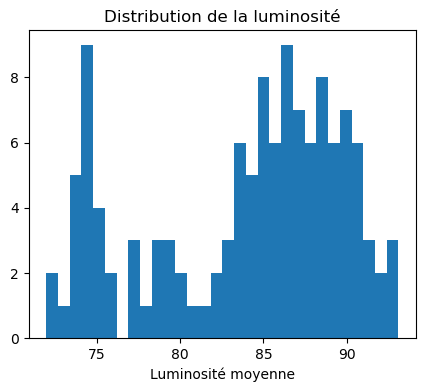

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_leather = [info["width"] for info in self.image_info]
        heights_leather = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_leather, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_leather, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_leather = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_leather, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_leather = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_leather, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\leather"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## 8) Pièce industrielle **pill**:

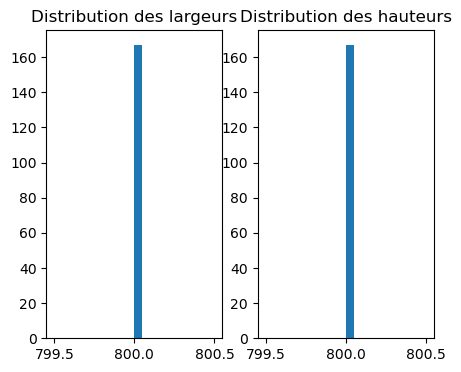

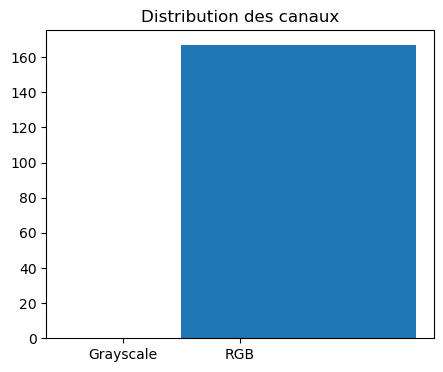

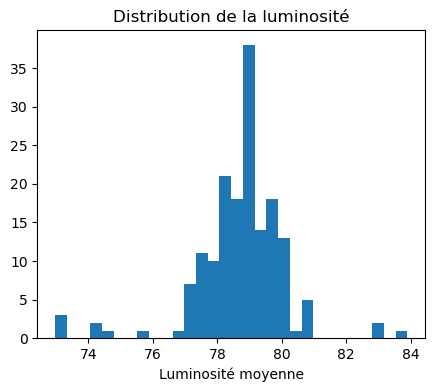

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_pill = [info["width"] for info in self.image_info]
        heights_pill = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_pill, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_pill, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_pill = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_pill, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_pill = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_pill, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\pill"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## 9) Pièce industrielle **screw**:

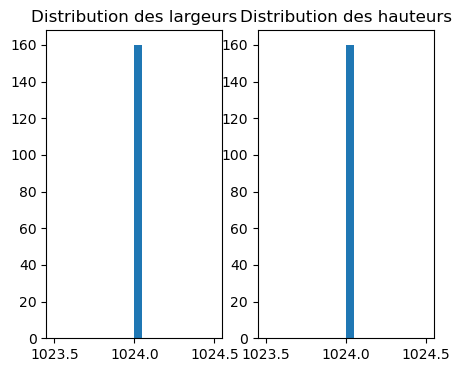

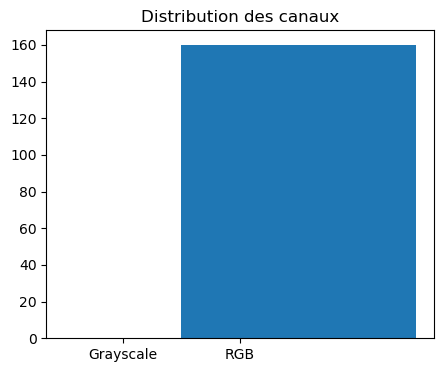

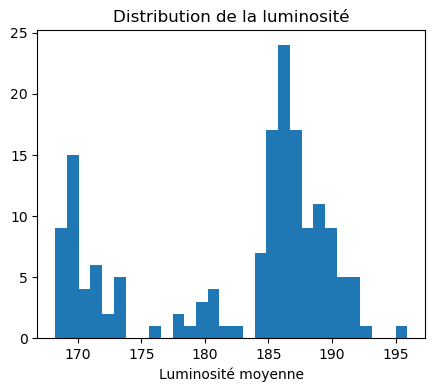

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_screw = [info["width"] for info in self.image_info]
        heights_screw = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_screw, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_screw, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_screw = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_screw, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_screw = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_screw, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\screw"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## 10) Pièce industrielle **tile**:

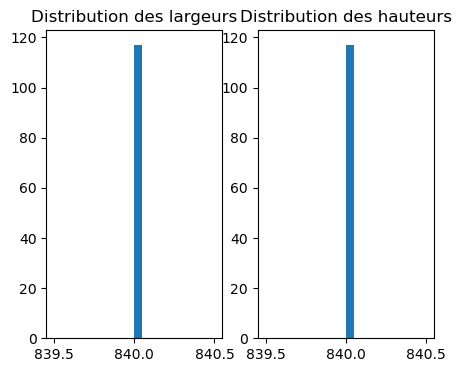

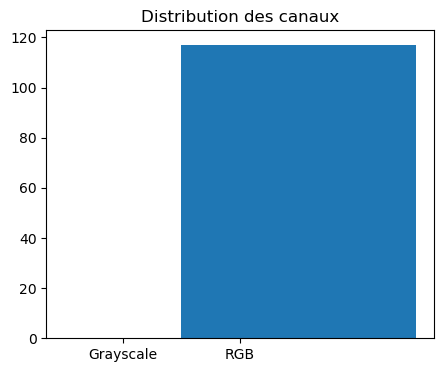

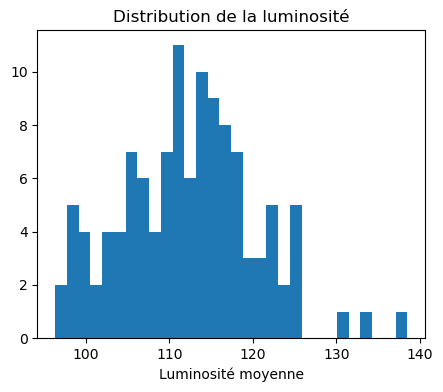

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_tile= [info["width"] for info in self.image_info]
        heights_tile = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_tile, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_tile, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_tile = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_tile, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_tile = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_tile, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\tile"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## 11) Pièce industrielle **toothbrush**:

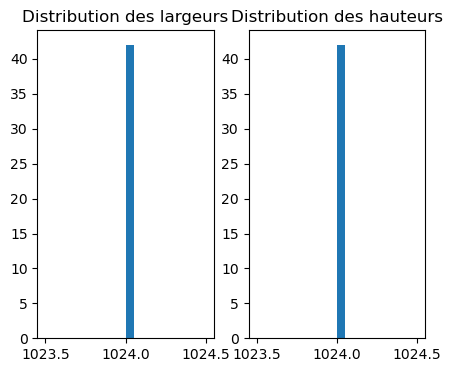

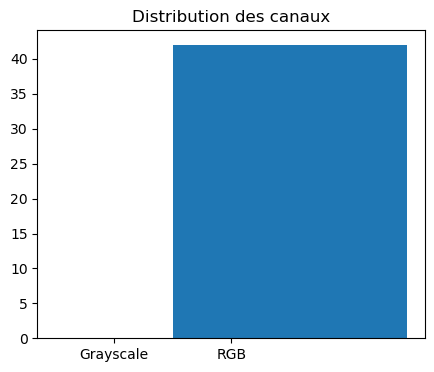

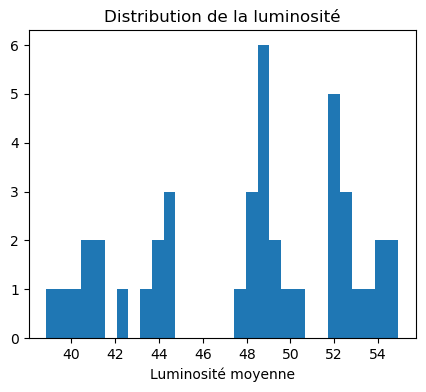

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_toothbrush= [info["width"] for info in self.image_info]
        heights_toothbrush = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_toothbrush, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_toothbrush, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_toothbrush = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_toothbrush, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_toothbrush = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_toothbrush, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\toothbrush"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## 12) Pièce industrielle **transistor**:

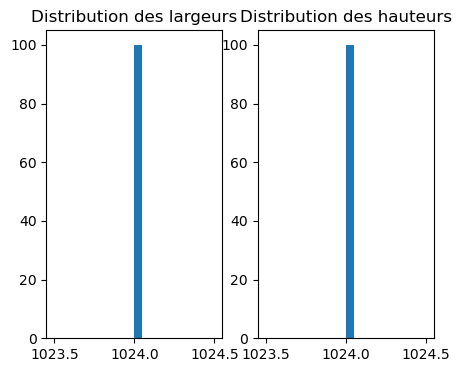

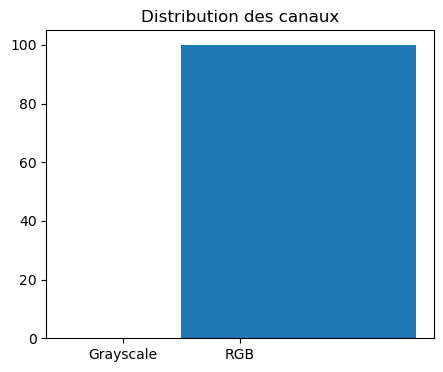

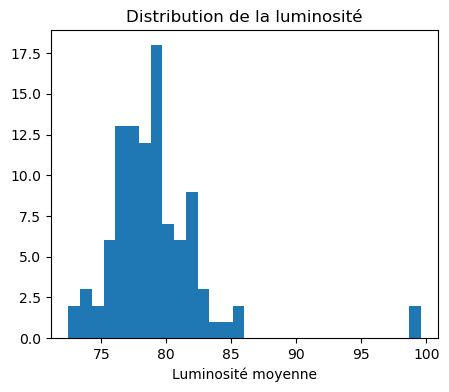

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_transistor= [info["width"] for info in self.image_info]
        heights_transistor = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_transistor, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_transistor, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_transistor = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_transistor, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_transistor = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_transistor, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\transistor"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## 13) Pièce industrielle **wood**:

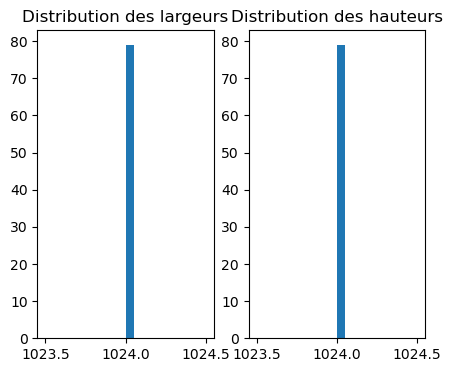

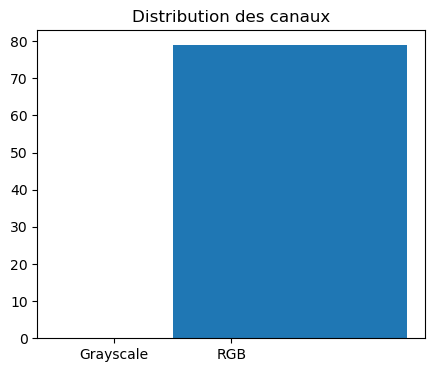

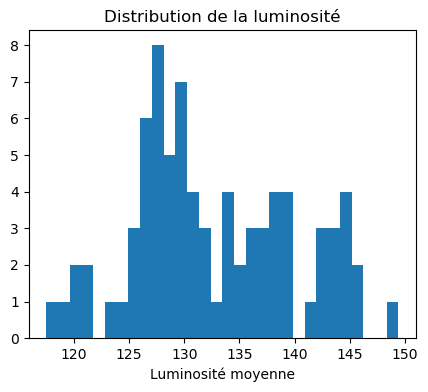

 le nombre d'image total est de : 79
 le nombre d'image non lues est de : 0


In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        self.total_image=0
        self.no_read_image=0

        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)
                    self.total_image+=1

                    if img is None:
                        self.no_read_image+=1
                        continue


                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()


                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_wood= [info["width"] for info in self.image_info]
        heights_wood = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_wood, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_wood, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_wood = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_wood, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_wood = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_wood, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()



## calculer le nombre d'image non lues par rapport au nombre d'image total:
    def image_counts(self):
        print(f" le nombre d'image total est de : {self.total_image}")
        print(f" le nombre d'image non lues est de : {self.no_read_image}")





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\wood"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()
explorer.image_counts()


## 14) Pièce industrielle **zipper**:

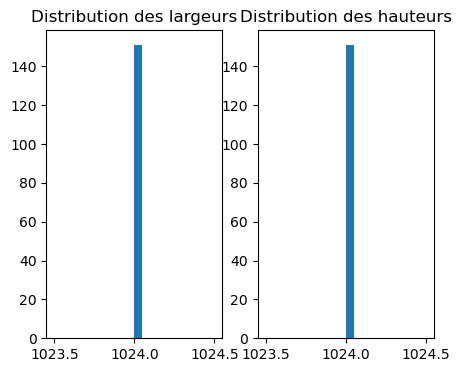

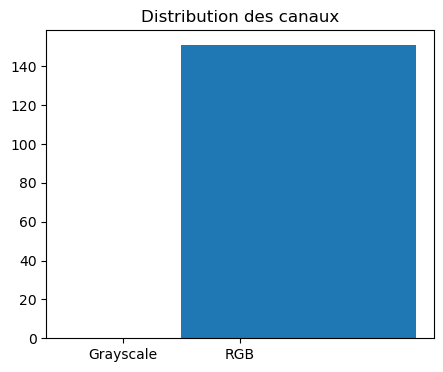

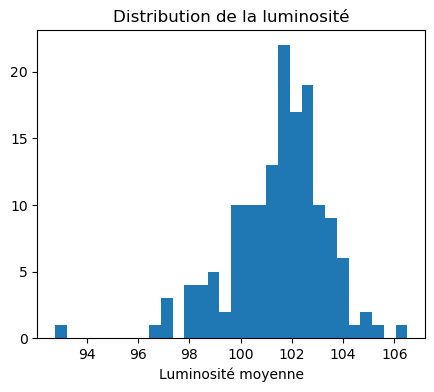

In [ ]:
class MVTecExplorer:
##initialiser la classe:
    def __init__(self, piece_industrielles):
        self.piece_industrielles = piece_industrielles
        self.train_path = os.path.join(piece_industrielles, "train", "good")
        self.test_path = os.path.join(piece_industrielles, "test")
        self.mask_path = os.path.join(piece_industrielles, "ground_truth")

        self.image_info = []

###
    def load_images_info(self):
        for root, _, files in os.walk(self.test_path):
            for file in files:
                if file.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(root, file)
                    img = cv2.imread(img_path)

                    if img is None:
                        continue

                    h, w = img.shape[:2]
                    channels = img.shape[2] if len(img.shape) == 3 else 1
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    brightness = gray.mean()

                    label = os.path.basename(root)

                    self.image_info.append({
                        "path": img_path,
                        "width": w,
                        "height": h,
                        "channels": channels,
                        "brightness": brightness,
                        "label": label
                    })


##fonction qui permet de d'analyser les taille des images de chaque dossier d'une piece:
    def plot_image_sizes(self):
        widths_zipper= [info["width"] for info in self.image_info]
        heights_zipper = [info["height"] for info in self.image_info]

        plt.figure(figsize=(5,4))

        plt.subplot(1,2,1)
        plt.hist(widths_zipper, bins=20)
        plt.title("Distribution des largeurs")

        plt.subplot(1,2,2)
        plt.hist(heights_zipper, bins=20)
        plt.title("Distribution des hauteurs")

        plt.show()



## Analyse de RGB et des images en gris des images de chaque dossier d'une piece:
    def plot_channel_distribution(self):
        channels_zipper = [info["channels"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(channels_zipper, bins=[0.5,1.5,3.5])
        plt.xticks([1,2], ["Grayscale", "RGB"])
        plt.title("Distribution des canaux")

        plt.show()


## analyse de la luminosité des images :

    def plot_brightness(self):
        brightness_zipper = [info["brightness"] for info in self.image_info]

        plt.figure(figsize=(5,4))
        plt.hist(brightness_zipper, bins=30)
        plt.title("Distribution de la luminosité")
        plt.xlabel("Luminosité moyenne")
        plt.show()





## les différentes fonction :
piece_industrielles = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection\zipper"

explorer = MVTecExplorer(piece_industrielles)
explorer.load_images_info()
explorer.plot_image_sizes()
explorer.plot_channel_distribution()
explorer.plot_brightness()



## II)Shape de l'ensemble des images des données MvTec étudiées:

In [ ]:


categories = [p.name for p in Path(f"../Projet/mvtec_anomaly_detection/").iterdir() if p.is_dir()]


data_sizes = []

for category in categories:

    train_dir = Path(f"../Projet/mvtec_anomaly_detection/{category}/train")
    test_dir = Path(f"../Projet/mvtec_anomaly_detection/{category}/test")

    train_files = [f for f in train_dir.rglob('*') if f.is_file()]
    test_files = [f for f in test_dir.rglob('*') if f.is_file()]


    formats_train = []
    modes_train = []
    for img in train_files:
        with Image.open(img) as img:
            width, height= img.size
            formats_train.append(img.format)
            modes_train.append(img.mode)

            data_sizes.append({
                "piece": category,
                "set": "train",
                "width": width,
                "height": height,
                "format": img.format,
                "mode": img.mode
            })


    formats_test = []
    modes_test = []
    for img_path in test_files:
        with Image.open(img_path) as img:
            width, height = img.size
            formats_test.append(img.format)
            modes_test.append(img.mode)

            data_sizes.append({
                "piece": category,
                "set": "test",
                "width": width,
                "height": height,
                "format": img.format,
                "mode": img.mode
            })


df_sizes = pd.DataFrame(data_sizes)

#print(df_sizes.head())
#print(df_sizes.info())



df_unique = df_sizes.groupby('piece').agg({
    'set': 'unique',
    'width': 'unique',
    'height': 'unique',
    'mode': 'unique'
}).reset_index()

texture = ['carpet', 'grid', 'leather', 'tile', 'wood']
objet = ['bottle', 'cable', 'capsule', 'hazelnut', 'metal_nut',
         'pill', 'screw', 'toothbrush', 'transistor', 'zipper']

# Ajouter une colonne "category" dans df_unique
df_unique['category'] = df_unique['piece'].apply(
    lambda x: 'texture' if x in texture else ('objet' if x in objet else 'inconnu')
)
df_unique

,piece,set,width,height,mode,category
0,bottle,"[train, test]",[900],[900],[RGB],objet
1,cable,"[train, test]",[1024],[1024],[RGB],objet
2,capsule,"[train, test]",[1000],[1000],[RGB],objet
3,carpet,"[train, test]",[1024],[1024],[RGB],texture
4,grid,"[train, test]",[1024],[1024],[L],texture
5,hazelnut,"[train, test]",[1024],[1024],[RGB],objet
6,leather,"[train, test]",[1024],[1024],[RGB],texture
7,metal_nut,"[train, test]",[700],[700],[RGB],objet
8,pill,"[train, test]",[800],[800],[RGB],objet
9,screw,"[train, test]",[1024],[1024],[L],objet


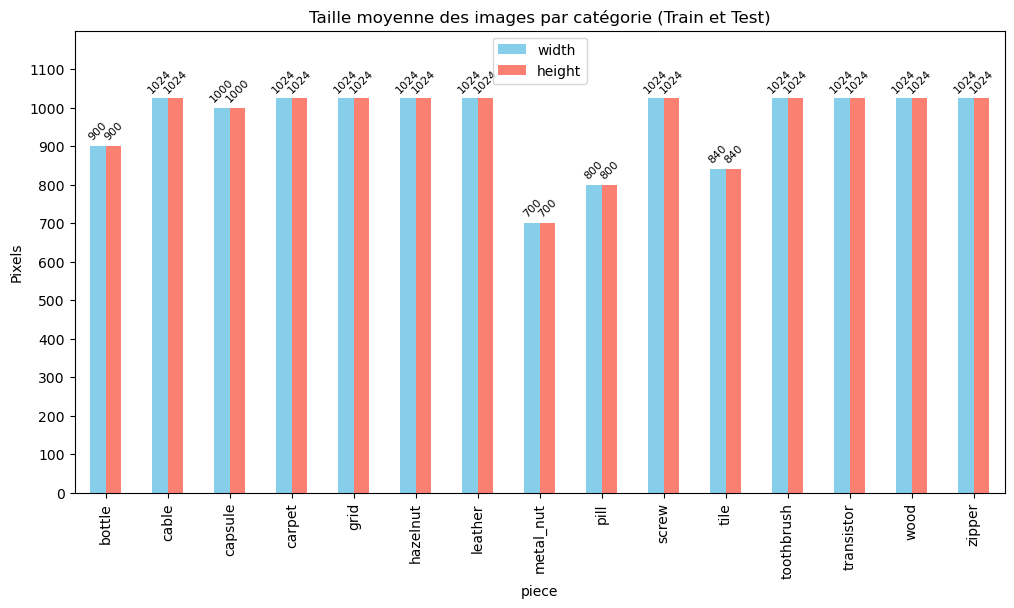

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcul des moyennes
df_avg = df_sizes.groupby('piece')[['width','height']].mean().reset_index()

# Création du graphique
ax = df_avg.plot(x='piece', kind='bar', figsize=(12,6), color=['skyblue','salmon'])

plt.ylabel("Pixels")
plt.title("Taille moyenne des images par catégorie (Train et Test)")
plt.ylim(0, 1200)
plt.yticks(np.arange(0, 1101, 100))  # pas de 100

# Ajouter les valeurs au-dessus de chaque barre avec rotation et taille réduite
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, rotation=45, fontsize=8)

plt.show()


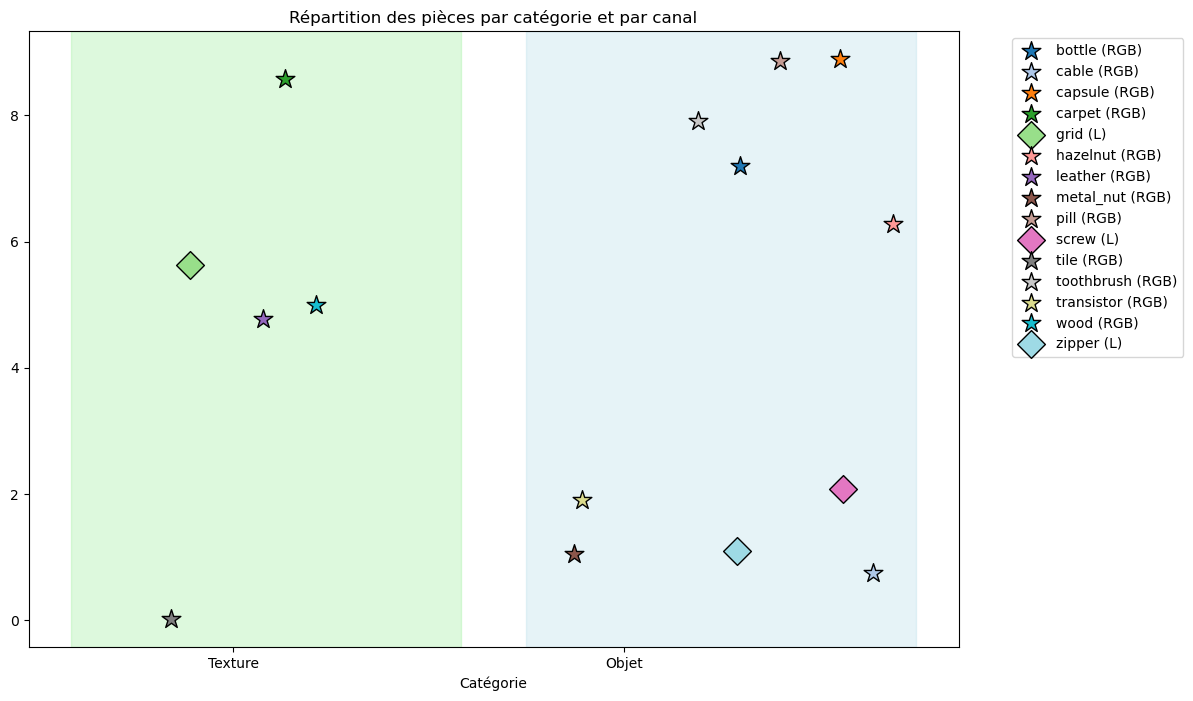

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# On récupère uniquement une ligne par pièce avec son mode et catégorie
df_unique_piece = df_sizes[['piece', 'category', 'mode']].drop_duplicates()

# Définir les zones X pour chaque catégorie
category_bounds = {
    'texture': (0, 6),
    'objet': (7, 13)
}

# Générer un point aléatoire par pièce dans sa zone X
x_positions = []
y_positions = []
for _, row in df_unique_piece.iterrows():
    x_min, x_max = category_bounds[row['category']]
    x_positions.append(np.random.uniform(x_min, x_max))
    y_positions.append(np.random.uniform(0, 10))  # position aléatoire verticale

df_unique_piece['x_random'] = x_positions
df_unique_piece['y_random'] = y_positions

# Couleur par pièce
pieces = df_unique_piece['piece'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(pieces)))
piece_color_dict = dict(zip(pieces, colors))

# Forme par mode
modes = df_unique_piece['mode'].unique()
markers = ['*', 'D']  # cercles, carrés, étoiles, etc.
mode_marker_dict = dict(zip(modes, markers[:len(modes)]))

# Création du graphique
plt.figure(figsize=(12, 8))

# Fond coloré par catégorie
for cat, (x_min, x_max) in category_bounds.items():
    plt.axvspan(x_min, x_max, color='lightgreen' if cat=='texture' else 'lightblue', alpha=0.3)

# Scatter : 1 point par pièce avec couleur par pièce et forme par mode
for _, row in df_unique_piece.iterrows():
    plt.scatter(
        row['x_random'], row['y_random'],
        color=piece_color_dict[row['piece']],
        marker=mode_marker_dict[row['mode']],
        s=200,
        edgecolor='k',
        label=f"{row['piece']} ({row['mode']})"
    )

plt.xticks([2.5, 8.5], ['Texture', 'Objet'])
plt.xlabel("Catégorie")

plt.title("Répartition des pièces par catégorie et par canal")


# Légende sans doublons
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


Les explorations des données de MvTEc effectuées ci-dessus nous montre des tailles d'images différentes entre pieces industrielles étudier. les tailles variées entre 700 et 1024.
* Afin de determiner la taille avec laquelle notre mùodele est le plus performant, on testera plusieurs taille et on comarera les performances du modele afin de choisir la taille optimale. ( pour les CNN la taille

## Determination des valeurs aberantes des données masque de chaque anomalies:

In [ ]:
df

,piece,defect_type,anomaly_pixels,anomaly_ratio
0,bottle,broken_large,88192,0.108879
1,bottle,broken_large,76641,0.094619
2,bottle,broken_large,125835,0.155352
3,bottle,broken_large,222091,0.274186
4,bottle,broken_large,33132,0.040904
...,...,...,...,...
1253,zipper,squeezed_teeth,13429,0.012807
1254,zipper,squeezed_teeth,10562,0.010073
1255,zipper,squeezed_teeth,11726,0.011183
1256,zipper,squeezed_teeth,21545,0.020547


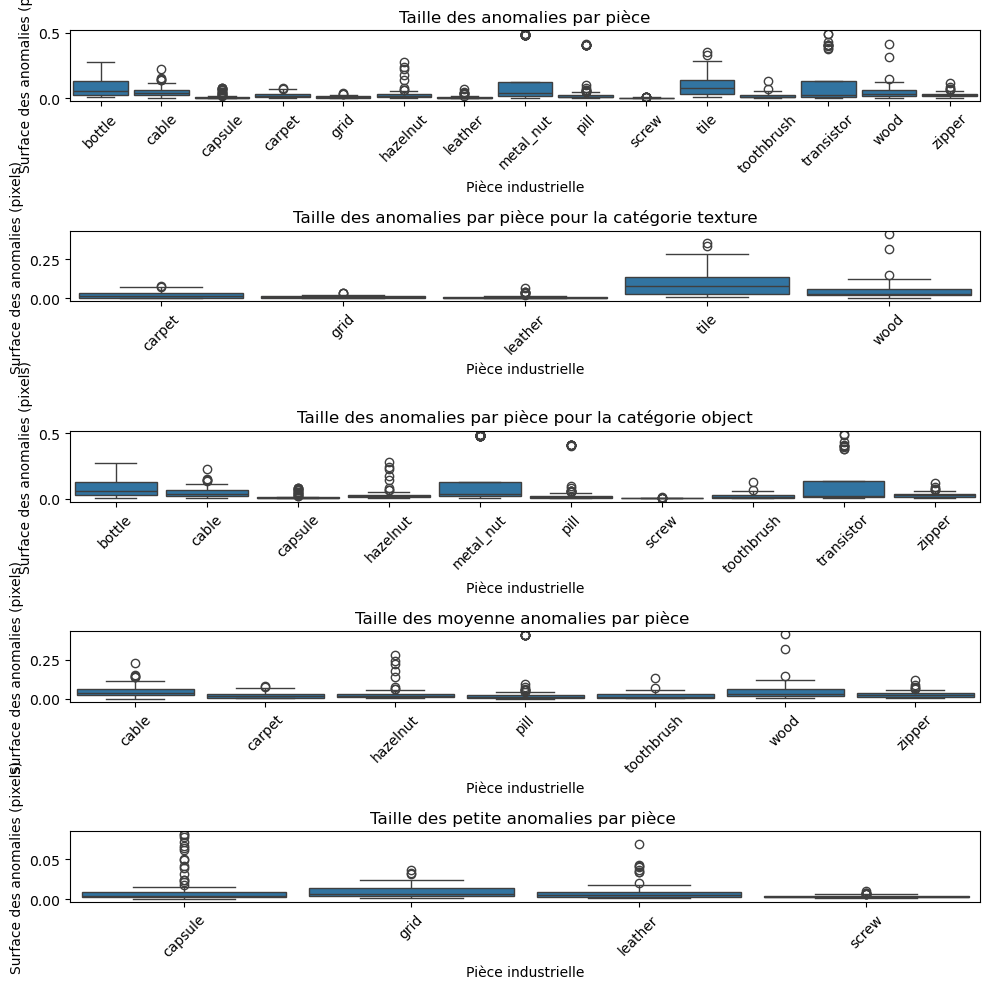

In [ ]:
def mask_area(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    anomaly_pixels = np.count_nonzero(mask)
    total_pixels = mask.shape[0] * mask.shape[1]

    return anomaly_pixels, anomaly_pixels / total_pixels



root_dir = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection"

data = []

for piece in os.listdir(root_dir):
    piece_path = os.path.join(root_dir, piece)
    gt_path = os.path.join(piece_path, "ground_truth")

    if not os.path.isdir(gt_path):
        continue

    for defect_type in os.listdir(gt_path):
        defect_path = os.path.join(gt_path, defect_type)
        if not os.path.isdir(defect_path):
            continue

        for file in os.listdir(defect_path):
            if file.endswith((".png", ".jpg")):
                mask_path = os.path.join(defect_path, file)
                anomaly_px, anomaly_ratio = mask_area(mask_path)

                if anomaly_px is not None:
                    data.append({"piece": piece,"defect_type": defect_type, "anomaly_pixels": anomaly_px,"anomaly_ratio": anomaly_ratio})

## transformer data en DataFrame
df = pd.DataFrame(data)

## extraire les dpieces de type texture:

texture= ['carpet', 'grid', 'leather', 'tile', 'wood']
df_texture = df[df['piece'].isin(texture)]

## extraire les pieces de type objet:
objet= ['bottle', 'cable', 'capsule', 'hazelnut', 'metal_nut','pill', 'screw', 'toothbrush', 'transistor', 'zipper']
df_object = df[df['piece'].isin(objet)]


##extraire les pieces avec de moyennes anomalies:
moyenne_anomalies= [ 'cable',  'hazelnut','pill',  'toothbrush','zipper','carpet','wood']
df_moyenne_anomalies = df[df['piece'].isin(moyenne_anomalies)]

##extraire les pieces avec de petite anomalies:
petite_anomalies= [  'capsule',  'screw',  'grid', 'leather']
df_petite_anomalies = df[df['piece'].isin(petite_anomalies)]



plt.figure(figsize=(10, 10))

plt.subplot(5,1,1)

sns.boxplot(data=df, x="piece",y="anomaly_ratio",width=0.9, color="#1f77b4" )

plt.xticks(rotation=45)
plt.title("Taille des anomalies par pièce")
plt.ylabel("Surface des anomalies (pixels)")
plt.xlabel("Pièce industrielle")





plt.subplot(5,1,2)

sns.boxplot(data=df_texture, x="piece",y="anomaly_ratio",width=0.9, color="#1f77b4" )

plt.xticks(rotation=45)
plt.title("Taille des anomalies par pièce pour la catégorie texture")
plt.ylabel("Surface des anomalies (pixels)")
plt.xlabel("Pièce industrielle")





plt.subplot(5,1,3)

sns.boxplot(data=df_object, x="piece",y="anomaly_ratio",width=0.9, patch_artist=True, color="#1f77b4" )

plt.xticks(rotation=45)
plt.title("Taille des anomalies par pièce pour la catégorie object")
plt.ylabel("Surface des anomalies (pixels)")
plt.xlabel("Pièce industrielle")
plt.tight_layout()



plt.subplot(5,1,4)

sns.boxplot(data=df_moyenne_anomalies, x="piece",y="anomaly_ratio",width=0.9, patch_artist=True, color="#1f77b4" )

plt.xticks(rotation=45)
plt.title("Taille des moyenne anomalies par pièce ")
plt.ylabel("Surface des anomalies (pixels)")
plt.xlabel("Pièce industrielle")
plt.tight_layout()


plt.subplot(5,1,5)

sns.boxplot(data=df_petite_anomalies, x="piece",y="anomaly_ratio",width=0.9, patch_artist=True, color="#1f77b4" )

plt.xticks(rotation=45)
plt.title("Taille des petite anomalies par pièce ")
plt.ylabel("Surface des anomalies (pixels)")
plt.xlabel("Pièce industrielle")
plt.tight_layout()

plt.show()






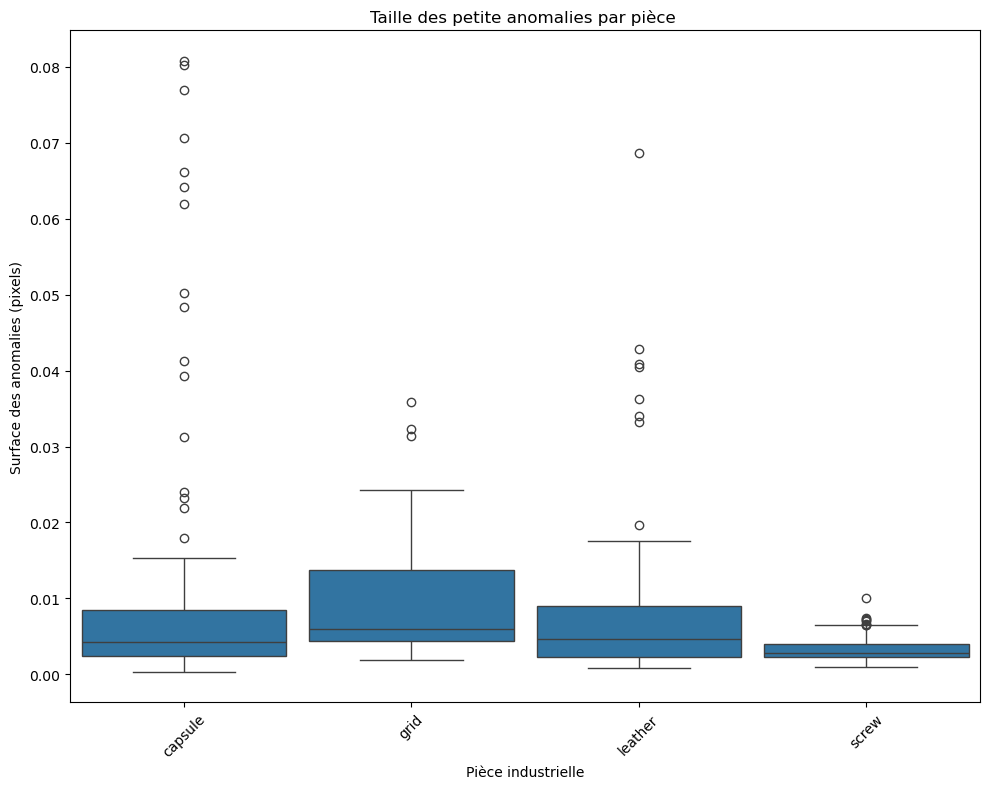

In [ ]:
plt.figure(figsize=(10, 8))


sns.boxplot(data=df_petite_anomalies, x="piece",y="anomaly_ratio",width=0.9, patch_artist=True, color="#1f77b4" )

plt.xticks(rotation=45)
plt.title("Taille des petite anomalies par pièce ")
plt.ylabel("Surface des anomalies (pixels)")
plt.xlabel("Pièce industrielle")
plt.tight_layout()

plt.show()

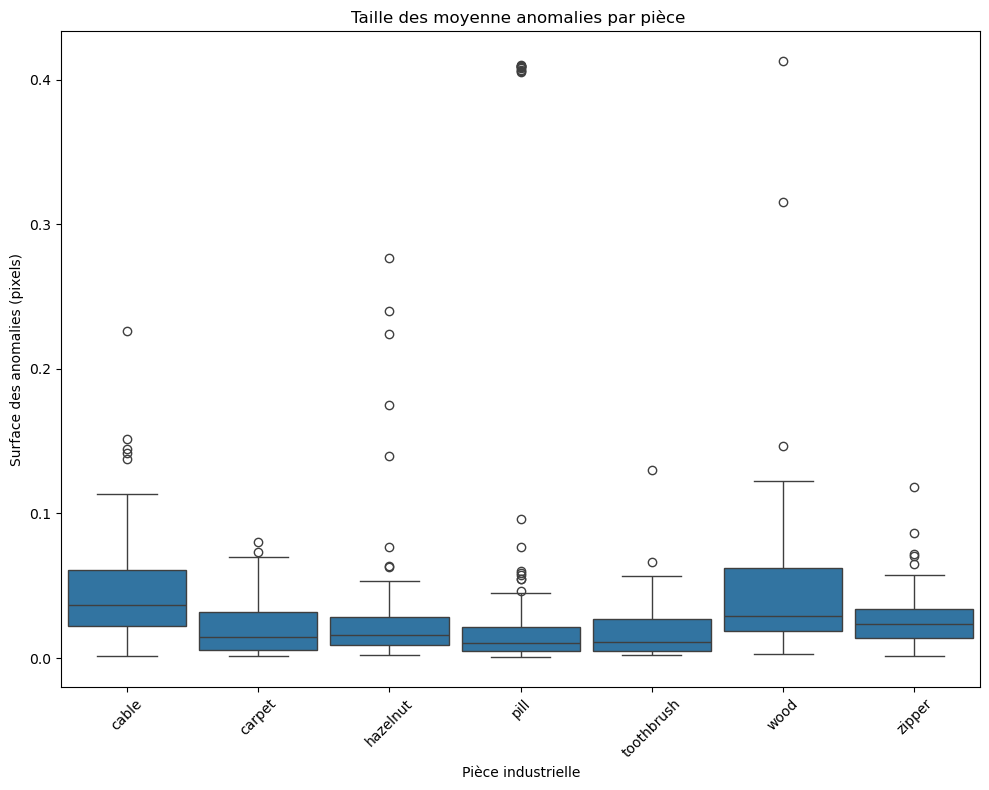

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df_moyenne_anomalies, x="piece",y="anomaly_ratio",width=0.9, patch_artist=True, color="#1f77b4" )

plt.xticks(rotation=45)
plt.title("Taille des moyenne anomalies par pièce ")
plt.ylabel("Surface des anomalies (pixels)")
plt.xlabel("Pièce industrielle")
plt.tight_layout()
plt.show()

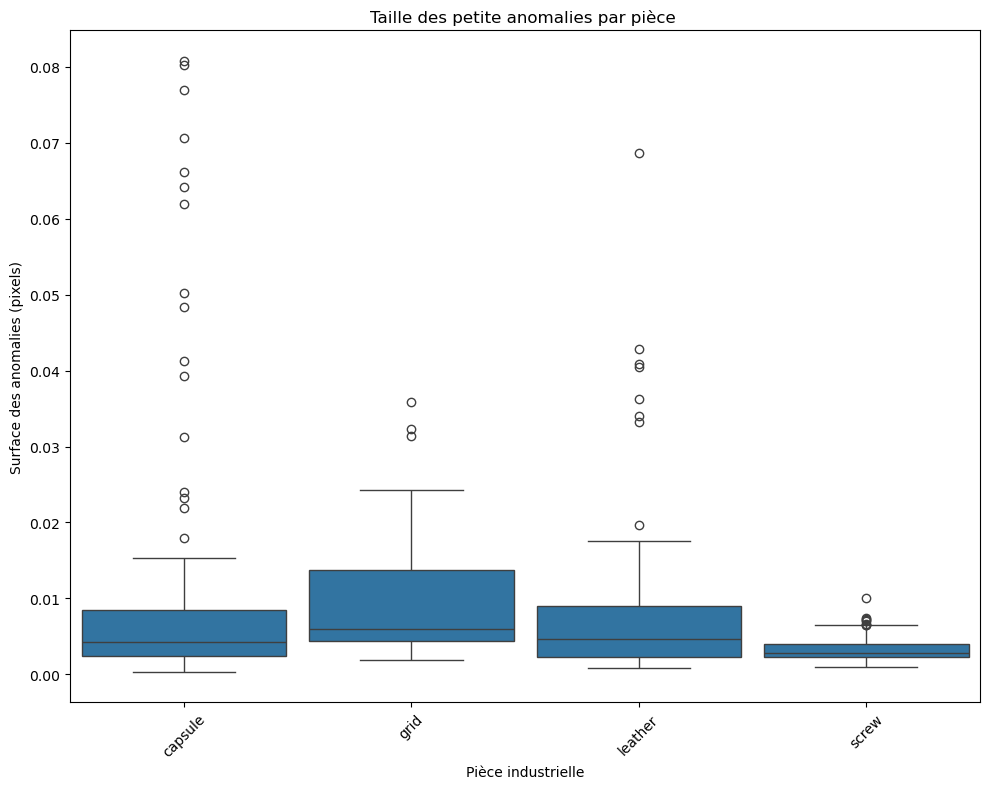

In [ ]:
plt.figure(figsize=(10, 8))


sns.boxplot(data=df_petite_anomalies, x="piece",y="anomaly_ratio",width=0.9, patch_artist=True, color="#1f77b4" )

plt.xticks(rotation=45)
plt.title("Taille des petite anomalies par pièce ")
plt.ylabel("Surface des anomalies (pixels)")
plt.xlabel("Pièce industrielle")
plt.tight_layout()

plt.show()


In [ ]:

# IMPORTS

import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# surface des anomalies

def mask_area(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    anomaly_pixels = np.count_nonzero(mask)
    total_pixels = mask.shape[0] * mask.shape[1]
    return anomaly_pixels, anomaly_pixels / total_pixels



# CHARGEMENT DES DONNÉES

root_dir = r"C:\Users\hanou\OneDrive\Formation_DS\Projet\mvtec_anomaly_detection"
data = []

for piece in os.listdir(root_dir):
    piece_path = os.path.join(root_dir, piece)
    gt_path = os.path.join(piece_path, "ground_truth")

    if not os.path.isdir(gt_path):
        continue

    for defect_type in os.listdir(gt_path):
        defect_path = os.path.join(gt_path, defect_type)
        if not os.path.isdir(defect_path):
            continue

        for file in os.listdir(defect_path):
            if file.endswith((".png", ".jpg")):
                mask_path = os.path.join(defect_path, file)
                result = mask_area(mask_path)

                if result is not None:
                    anomaly_px, anomaly_ratio = result
                    data.append({
                        "piece": piece,
                        "defect_type": defect_type,
                        "anomaly_pixels": anomaly_px,
                        "anomaly_ratio": anomaly_ratio
                    })

df = pd.DataFrame(data)



# STATISTIQUES DESCRIPTIVES

stats = df.groupby("piece")["anomaly_ratio"].agg(
    mean="mean",
    std="std",
    Q1=lambda x: x.quantile(0.25),
    median="median",
    Q3=lambda x: x.quantile(0.75),
    min="min",
    max="max"
)

stats["IQR"] = stats["Q3"] - stats["Q1"]
stats["lower_bound"] = stats["Q1"] - 1.5 * stats["IQR"]
stats["upper_bound"] = stats["Q3"] + 1.5 * stats["IQR"]

print("\n===== STATISTIQUES DESCRIPTIVES PAR PIÈCE =====\n")
print(stats)


# PRÉPARATION DU TABLEAU POUR EXPORT


# Copie pour éviter toute modification accidentelle
stats_export = stats.copy()

# Passage en pourcentage (plus lisible)
stats_export[['mean', 'std', 'Q1', 'median', 'Q3', 'min', 'max',
              'IQR', 'lower_bound', 'upper_bound']] *= 100

# Arrondi pour lisibilité
stats_export = stats_export.round(2)


# MISE EN FORME AVEC CODE COULEUR


styled_stats = (
    stats_export
    .style
    .background_gradient(
        cmap="Reds",
        axis=0  # gradient par colonne
    )
    .format("{:.2f}")
    .set_caption(
        "Statistiques descriptives des superficies des anomalies par pièce (en %)"
    )
)


# EXPORT EXCEL


output_file = "statistiques_anomalies_MVTec1.xlsx"

styled_stats.to_excel(
    output_file,
    engine="openpyxl"
)

print(f"\n✅ Tableau exporté avec succès : {output_file}")





# DÉTECTION DES VALEURS ABERRANTES

def detect_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return group[(group < lower) | (group > upper)]

outliers = df.groupby("piece")["anomaly_ratio"].apply(detect_outliers)

print("\n===== VALEURS ABERRANTES DÉTECTÉES =====\n")
print(outliers)



# SÉPARATION DES CATÉGORIES

texture = ['carpet', 'grid', 'leather', 'tile', 'wood']
objet = ['bottle', 'cable', 'capsule', 'hazelnut', 'metal_nut',
         'pill', 'screw', 'toothbrush', 'transistor', 'zipper']
petite_anomalies = ['cable', 'capsule', 'hazelnut','pill', 'screw',
                    'toothbrush','zipper','carpet', 'grid', 'leather', 'wood']

df_texture = df[df['piece'].isin(texture)]
df_object = df[df['piece'].isin(objet)]
df_petite_anomalies = df[df['piece'].isin(petite_anomalies)]





===== STATISTIQUES DESCRIPTIVES PAR PIÈCE =====

                mean       std        Q1    median        Q3       min  \
piece                                                                    
bottle      0.076166  0.057601  0.025741  0.057178  0.128291  0.005757   
cable       0.046812  0.036827  0.022298  0.036808  0.061176  0.001436   
capsule     0.011089  0.018403  0.002479  0.004295  0.008496  0.000371   
carpet      0.021064  0.019463  0.005534  0.014757  0.031785  0.001650   
grid        0.009452  0.007930  0.004402  0.006015  0.013798  0.001884   
hazelnut    0.033546  0.053394  0.009169  0.016158  0.028548  0.002329   
leather     0.008742  0.011228  0.002291  0.004615  0.008995  0.000886   
metal_nut   0.144888  0.195727  0.018982  0.036714  0.123010  0.004357   
pill        0.039773  0.097710  0.004889  0.010327  0.021356  0.000505   
screw       0.003355  0.001666  0.002321  0.002879  0.003984  0.000985   
tile        0.098023  0.077735  0.030761  0.079303  0.139413  

In [ ]:
stats


,mean,std,Q1,median,Q3,min,max,IQR,lower_bound,upper_bound
piece,,,,,,,,,,
bottle,0.076166,0.057601,0.025741,0.057178,0.128291,0.005757,0.274186,0.102549,-0.128083,0.282115
cable,0.046812,0.036827,0.022298,0.036808,0.061176,0.001436,0.225807,0.038878,-0.036019,0.119492
capsule,0.011089,0.018403,0.002479,0.004295,0.008496,0.000371,0.080787,0.006017,-0.006546,0.017521
carpet,0.021064,0.019463,0.005534,0.014757,0.031785,0.001650,0.080171,0.026251,-0.033842,0.071161
grid,0.009452,0.007930,0.004402,0.006015,0.013798,0.001884,0.035815,0.009396,-0.009691,0.027891
hazelnut,0.033546,0.053394,0.009169,0.016158,0.028548,0.002329,0.276586,0.019379,-0.019900,0.057617
leather,0.008742,0.011228,0.002291,0.004615,0.008995,0.000886,0.068594,0.006703,-0.007763,0.019049
metal_nut,0.144888,0.195727,0.018982,0.036714,0.123010,0.004357,0.487247,0.104029,-0.137061,0.279053
pill,0.039773,0.097710,0.004889,0.010327,0.021356,0.000505,0.410036,0.016467,-0.019812,0.046057


[]

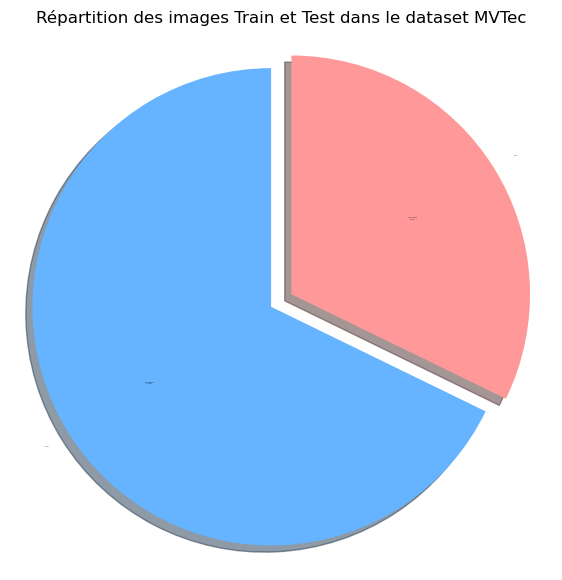

In [ ]:
##création d'un cummenbert :

# Nombre d'images
train_images = 3629
test_images = 1725

# Données pour le camembert
sizes = [train_images, test_images]
labels = ['Train', 'Test']
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)

# Fonction pour afficher nombre + pourcentage
def func(pct, allvals):
    absolute = int(pct/100.*sum(allvals))
    return "{:d} images\n({:.1f}%)".format(absolute, pct)

# Création du camembert
plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct=lambda pct: func(pct, sizes),
        startangle=90, colors=colors, explode=explode, shadow=True, textprops={'fontsize': 1})
plt.title("Répartition des images Train et Test dans le dataset MVTec")
plt.axis('equal')
plt.show()